# Donald Trump's Labor Market 

## Monthly Labor Market Analysis

## Description

This notebook provides a technical analysis of U.S. labor market dynamics using monthly nonfarm payroll data from the Federal Reserve Economic Data (FRED).

The analysis focuses on:

- Monthly changes in total nonfarm payrolls and foundational labor force metrics
- Moving averages and rolling baseline trendlines since 2016
- Structural shifts in employment behavior following recent systemic events

This notebook examines 'granular monthly variability' to identify transitions between:

- Stable expansion periods  
- Post-Covid recovery normalization  
- Late-cycle slowdown in 2024 
- Near-zero growth with increased volatility after 2024

Special attention is given from `2024 onward`, where labor market behavior transitioned into variance-dominated movement.

---

## Objectives

- Analyze U.S. payroll growth and core labor metrics from 2016 to present  
- Compare pre-COVID baseline conditions (2016–2019) with post-recovery behaviors (2021–present)  
- Identify the transition from steady growth to late-cycle labor market friction
- Detect regime shifts characterized by declining mean participation, widening demographic disparities, and increasing duration volatility  
- Contextualize employment behavior and labor supply drops around critical political, tariff, and judicial milestones  
- Provide a time-sensitive interpretation of labor market stability, latent economic slack, and ongoing structural risk

---

## Data Source & Core Matrices

- **Federal Reserve Economic Data (FRED)**

### 1. Key Performance Indicators (KPI Matrix)
* `PAYEMS:` Total Nonfarm Payroll Employment
* `CIVPART:` Labor Force Participation Rate
* `EMRATIO:` Employment-to-Population Ratio
* `UEMPLT5:` Unemployed Less than 5 Weeks
* `UEMP27OV:` Unemployed Longer than 27 Weeks
* `NILFWJN:` Not in Labor Force, Wants a Job

### 2. Demographic Slices (DEMO Matrix)
* `LNS14000003:` White Unemployment Rate
* `LNS14000006:` Black or African American Unemployment Rate
* `LNS14032183:` Asian Unemployment Rate
* `LNS14000009:` Hispanic or Latino Unemployment Rate
* `LNS14000001:` Adult Men Unemployment Rate
* `LNS14000002:` Adult Women Unemployment Rate
* `LNS14024887:` 16-24 Yrs. Unemployment Rate
* `LNS14000012:` 16-19 Yrs. Unemployment Rate

### Derived Analytics:
* **Monthly Job Growth:** First difference ($\Delta$) of PAYEMS  
* **3-Month Moving Average:** Rolling mean of monthly job growth  
* **12-Month Moving Average:** Trendline smoothing for the Employment-to-Population baseline  
* **Cross-Sectional Snapshots:** Single-month demographic disparity slicing  

All data streams are seasonally adjusted and reported in thousands of persons or raw percentages where applicable.

## Pre-Processing

### Install System Dependencies

In [10]:
%pip install pandas-datareader
%pip install seaborn
# Note: Uncomment below if necessary to ugrade installer
# !pip3 install --upgrade pip

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


### Import Python Libraries

In [11]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import pandas_datareader.data as web
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta

### Define Global Functions 

In [12]:
def add_event_lines(events, df_plot, y_position):
    """
    Plots vertical lines and labels for specific events within the date range of df_plot.
    
    Parameters:
    - events (dict): A dictionary of {'date_string': 'label'}.
    - df_plot (DataFrame): The pandas DataFrame being plotted (expects a DatetimeIndex).
    - y_position (float): The y-axis coordinate for the text labels.
    """
    for date_str, label in events.items():
        evt_date = pd.to_datetime(date_str)
        
        if df_plot.index.min() <= evt_date <= df_plot.index.max():
            plt.axvline(x=evt_date, 
                        color='black', 
                        linestyle=':', 
                        linewidth=1.2, 
                        alpha=0.7)
            
            plt.text(evt_date, y_position, label,
                     rotation=90, 
                     verticalalignment='top',
                     horizontalalignment='right',
                     fontsize=10,
                     fontweight='bold')
            
def add_event_lines_small(events, df_plot, y_position):
    """
    Plots vertical lines and labels for specific events within the date range of df_plot.
    
    Parameters:
    - events (dict): A dictionary of {'date_string': 'label'}.
    - df_plot (DataFrame): The pandas DataFrame being plotted (expects a DatetimeIndex).
    - y_position (float): The y-axis coordinate for the text labels.
    """
    for date_str, label in events.items():
        evt_date = pd.to_datetime(date_str)
        
        if df_plot.index.min() <= evt_date <= df_plot.index.max():
            plt.axvline(x=evt_date, 
                        color='black', 
                        linestyle=':', 
                        linewidth=1.2, 
                        alpha=0.7)
            
            plt.text(evt_date, y_position, label,
                     rotation=90, 
                     verticalalignment='top',
                     horizontalalignment='right',
                     fontsize=6,
                     fontweight='bold')

### Standard Unit Initial Timeframe

In [13]:
start = datetime(2016, 1, 1)
end = datetime.now()
str_current_date = end.strftime("%B %d, %Y")
plot_start = start + relativedelta(years=1)

### Sourcing

In [14]:
# Data source
df = web.DataReader("PAYEMS", "fred", start, end)

# Metrics
df["job_growth"] = df["PAYEMS"].diff()
df["ma_3"] = df["job_growth"].rolling(3).mean()


## Post-Covid Employment Dynamics (2021–Present)

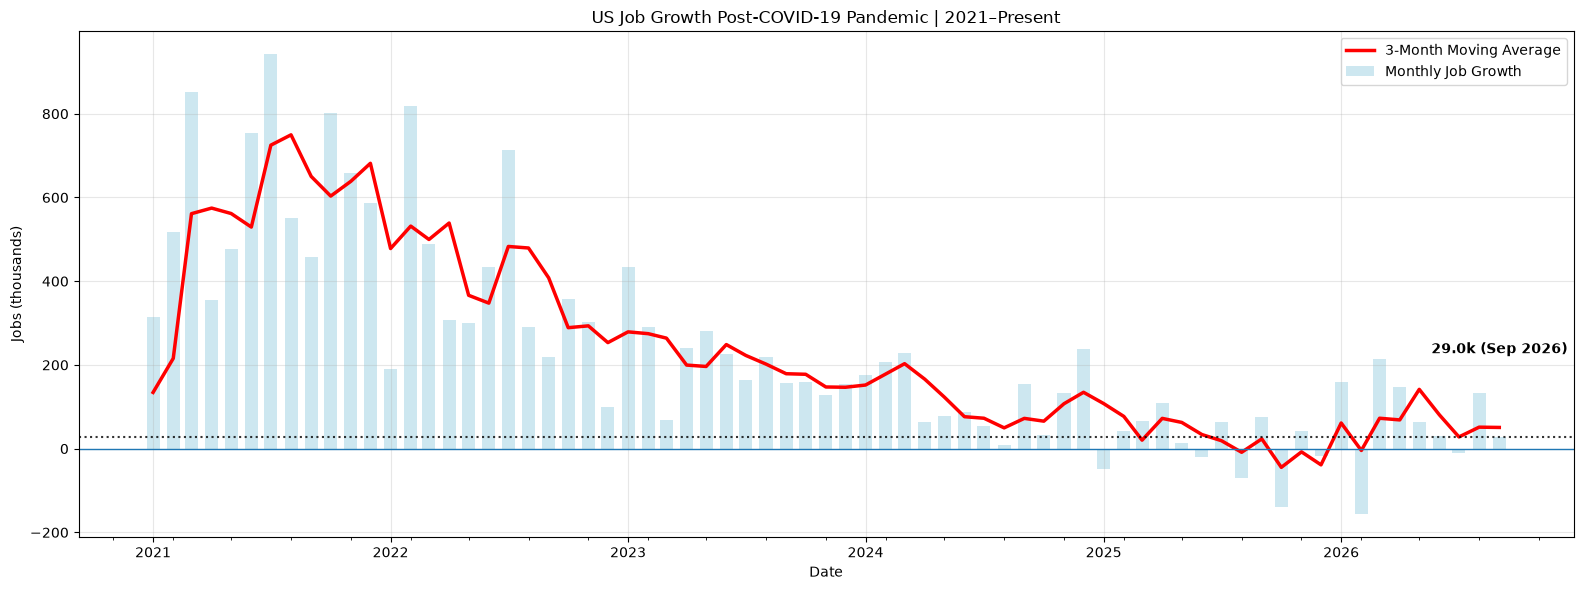

In [15]:
# 2021–Present | Post-COVID Recovery 
df_post = df[df.index >= "2021-01-01"]

# values
r_date = df["job_growth"].dropna().index[-1]
r_val = df["job_growth"].dropna().iloc[-1]
plt.figure(figsize=(16, 6))

plt.bar(df_post.index, 
        df_post["job_growth"], 
        color = "lightblue", 
        width = 20, 
        alpha = 0.6, 
        label = "Monthly Job Growth")
plt.plot(df_post.index, 
         df_post["ma_3"], 
         color = "red", 
         linewidth = 2.5, 
         label = "3-Month Moving Average")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.MonthLocator(interval = 3))

plt.axhline(0, linewidth=1)
plt.grid(alpha=0.3)

plt.title("US Job Growth Post-COVID-19 Pandemic | 2021–Present")
plt.ylabel("Jobs (thousands)")
plt.xlabel("Date")
plt.legend()

plt.annotate(f"{r_val:.1f}k ({r_date.strftime('%b %Y')})", 
             (r_date, r_val), 
             textcoords = "offset points", 
             xytext = (0,60), 
             ha = 'center', 
             weight = 'bold', 
             color = 'black')
plt.axhline(y=r_val, 
            color="#000000", 
            linestyle=':', 
            linewidth=1.5, 
            alpha=0.8)

plt.tight_layout()
plt.show()

## Late-Cycle Pandemic Recovery Behavior (2024–Present)

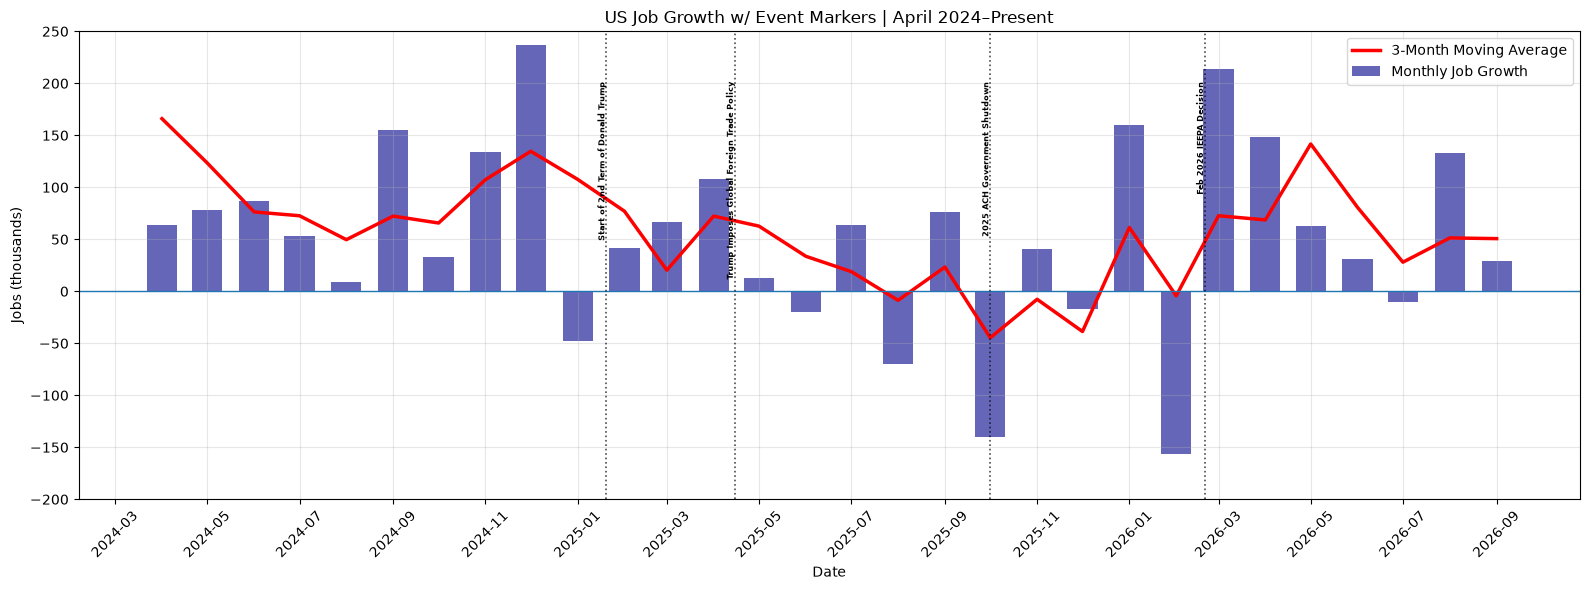

In [16]:
# Apr 2024 - Present : [Key dates:] 1/20/2025, 4/2/2025
df_focus = df[df.index >= "2024-04-01"]

plt.figure(figsize=(16, 6))

plt.bar(
    df_focus.index,
    df_focus["job_growth"],
    color="darkblue",
    width=20,
    alpha=0.6,
    label="Monthly Job Growth"
)

plt.plot(
    df_focus.index,
    df_focus["ma_3"],   
    color="red",
    linewidth=2.5,
    label="3-Month Moving Average"
)

# Key Events
events = {
    '2025-01-20': 'Start of 2nd Term of Donald Trump',
    '2025-4-15': 'Trump Imposes Global Foreign Trade Policy',
    '2025-10-01': '2025 ACH Government Shutdown',
    '2026-02-20': 'Feb 2026 IEEPA Decision',
}

# Formatting
y_max = df_focus["job_growth"].max()
y = y_max*.85

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.axhline(0, linewidth=1)
plt.ylim(-200, 250)

plt.grid(alpha=0.3)

plt.title("US Job Growth w/ Event Markers | April 2024–Present")

plt.ylabel("Jobs (thousands)")
plt.xlabel("Date")
add_event_lines_small(events,df,y)

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Advanced Metrics


### 1. Mathematical Framework & Derivative Indicators
To fully capture the late-cycle regime volatility and labor hoarding dynamics, our analysis tracks the interaction of three vital structural ratios:

* **Labor Force Participation Rate ($\text{LFPR}$):** Measures the active supply engine of the economy.
    $$\text{LFPR} = \left( \frac{\text{Labor Force}}{\text{Civilian Noninstitutional Population}} \right) \times 100$$
* **Employment-to-Population Ratio ($\text{EPOP}$):** Tracks the direct utilization rate of human capital. Unlike the headline unemployment rate ($U3$), $\text{EPOP}$ is isolated from arbitrary drops in participation, making it a cleaner proxy for structural labor demand.
    $$\text{EPOP} = \left( \frac{\text{Employed}}{\text{Civilian Noninstitutional Population}} \right) \times 100$$
* **Participation-to-Employment Gap ($\Delta_{PE}$):** Monitors divergence trends between active seekers and corporate absorption.

---

### 2. Analytical Focus Areas

#### A. Structural vs. Frictional Duration Splits
By segmenting the unemployed population by the duration of their joblessness, we isolate the underlying behavior of corporate hiring pipelines:
* **Frictional Liquidity ($<5$ Weeks):** Represents natural labor market churn, seasonal transitions, and frontline workforce re-allocations. Spikes here reflect a sudden surge in corporate separations/layoffs.
* **Structural Stagnation ($\ge 27$ Weeks):** Captures matching inefficiencies, persistent skill mismatches, and automated filtering out of long-term job seekers. When this metric rises alongside stable or falling short-term unemployment, it points to localized hiring freezes or systemic economic scarring.

#### B. Latent Labor Capacity (Marginally Attached Pool)
The data stream **"Not in Labor Force, Wants a Job Now" (`NILFWJN`)** acts as a crucial macroeconomic safety valve. 
* During periods of extreme regime volatility, traditional models fail to capture workers who drop out of active tracking metrics but remain ready to return.
* Monitoring this pool prevents underestimating the true level of economic slack when the headline participation rate declines unexpectedly.

---

### 3. Cross-Sectional Demographic Disparity
Labor market stress rarely hits evenly. By pulling granular, cross-sectional demographic matrix profiles, this analysis evaluates:
1.  **Generational Vulnerabilities:** Comparing entry-level cohorts (`16-19 Yrs.` and `16-24 Yrs.`) against prime-age workers to detect real-time adjustments in entry-level hiring sentiment.
2.  **Socioeconomic and Gender Asymmetries:** Tracking structural divergence paths across `White`, `Black or African American`, `Asian`, and `Hispanic` layers to pinpoint where macroeconomic policy shocks fall hardest during volatile periods.

In [17]:
start = datetime(2025, 1, 1)
end = datetime.now()

kpi_series = {
    'CIVPART': 'Labor Force Participation Rate',
    'EMRATIO': 'Employment-to-Population Ratio',
    'UEMPLT5': 'Unemployed Less than 5 Weeks',
    'UEMP27OV': 'Unemployed Longer than 27 Weeks',
    'NILFWJN': 'Not in Labor Force, Wants a Job'
}

demo_series = {
    'LNS14000003': 'White',
    'LNS14000006': 'Black or African American',
    'LNS14032183': 'Asian',
    'LNS14000009': 'Hispanic or Latino',
    'LNS14000001': 'Adult Men',
    'LNS14000002': 'Adult Women',
    'LNS14024887': '16-24 Yrs.',
    'LNS14000012': '16-19 Yrs.'
}

df_kpi = web.DataReader(list(kpi_series.keys()), 'fred', start, end)
df_kpi.rename(columns = kpi_series, inplace = True)

df_demo = web.DataReader(list(kpi_series.keys()), 'fred', start, end)
df_demo.rename(columns = demo_series, inplace = True)

## Metric 1: Labor Force Participation Rate (CIVPART)


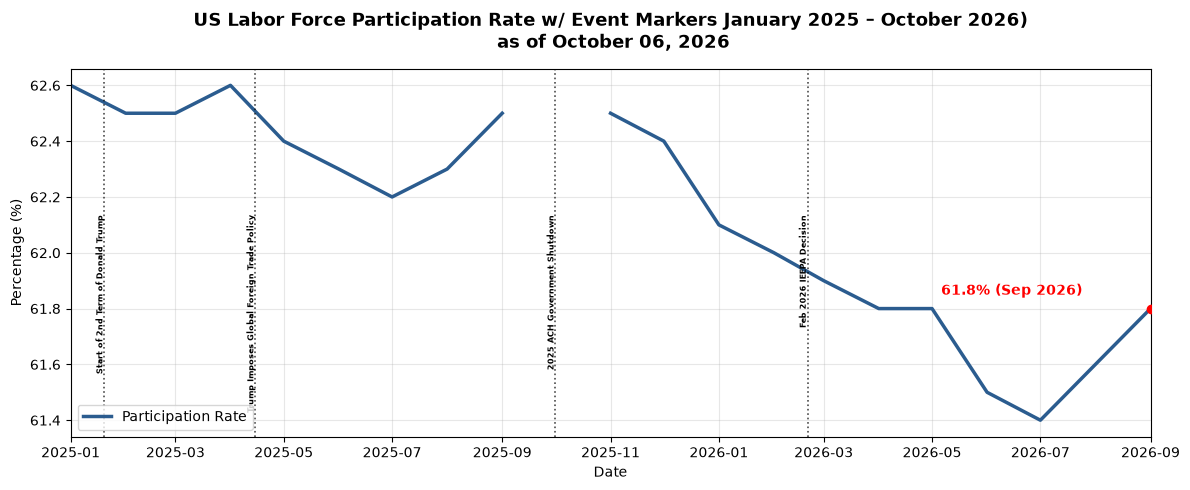

In [18]:

plt.figure(figsize=(12, 5))
plt.plot(df_kpi.index, df_kpi['Labor Force Participation Rate'], 
         color='#2b5c8f', 
         linewidth=2.5, 
         label='Participation Rate')

y_max = df_kpi['Labor Force Participation Rate'].max()

# Event label axis formatting

y = df_kpi['Labor Force Participation Rate'].mean()

ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xlim(datetime(2025, 1, 1), df_kpi.index.max())

plt.title(f'US Labor Force Participation Rate w/ Event Markers {start.strftime("%B %Y")} – {end.strftime("%B %Y")})\n as of {str_current_date}', fontsize=13, pad=15, weight='bold')
plt.ylabel("Percentage (%)")
plt.xlabel("Date")
plt.grid(alpha=0.3)
plt.legend(loc='lower left')
add_event_lines_small(events,df_kpi,y)
##ax.set_xticklabels(x_labels, rotation = 45, ha = 'right')

latest_date = df_kpi['Labor Force Participation Rate'].dropna().index[-1]
latest_val = df_kpi['Labor Force Participation Rate'].dropna().iloc[-1]
plt.scatter(latest_date, latest_val, color = 'red', zorder = 5)
plt.annotate(f"{latest_val:.1f}% ({latest_date.strftime('%b %Y')})", 
             (latest_date, latest_val), 
             textcoords = "offset points", 
             xytext = (-100,10), 
             ha = 'center', 
             weight = 'bold', 
             color = 'red')

plt.tight_layout()
plt.show()


## Metric 2: Employment-to-Population Ratio (EMRATIO)
### Trailing 24-Month Labor Utilization vs. 12-Month Moving Average Trend

C:\Users\library\AppData\Local\Temp\ipykernel_9624\273798234.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(x_labels, rotation = 45, ha = 'right')


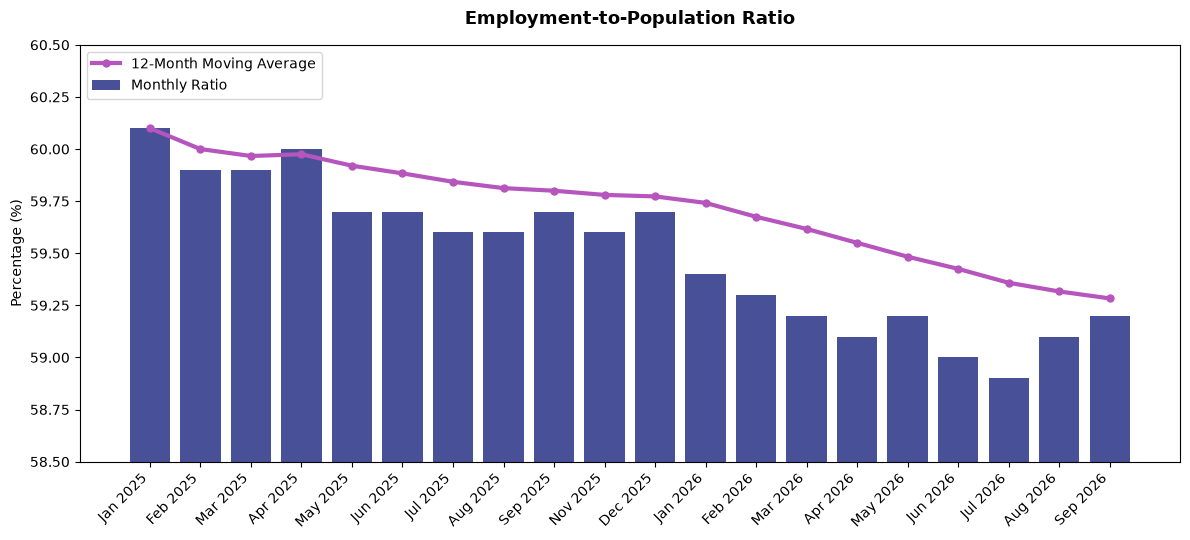

In [19]:
df_ratio = df_kpi[['Employment-to-Population Ratio']].dropna().tail(24).copy()
df_ratio['12M_MA'] = df_ratio['Employment-to-Population Ratio'].rolling(window = 12, min_periods = 1).mean()

fig, ax = plt.subplots(figsize = (12, 5.5))
x_labels = df_ratio.index.strftime('%b %Y')

sns.barplot(
    x = x_labels, 
    y = df_ratio['Employment-to-Population Ratio'], 
    ax = ax, 
    color = "#09198E", 
    alpha = 0.8, 
    label = 'Monthly Ratio'
)

ax.plot(
    range(len(df_ratio)), 
    df_ratio['12M_MA'], 
    color = "#b655bd", 
    linewidth = 3, 
    marker = 'o', 
    markersize = 5, 
    label = '12-Month Moving Average'
)

plt.title("Employment-to-Population Ratio", fontsize = 13, pad = 15, weight = 'bold')
ax.set_xticklabels(x_labels, rotation = 45, ha = 'right')
ax.set_ylabel("Percentage (%)")
ax.set_xlabel("")

y_min = df_ratio['Employment-to-Population Ratio'].min()
y_max = df_ratio['Employment-to-Population Ratio'].max()
ax.set_ylim(y_min - 0.4, y_max + 0.4)

ax.legend(loc = 'upper left', frameon = True)
plt.tight_layout()
plt.show()

## Metric 3: Unemployment Duration Dynamics (UEMPLT5 vs. UEMP27OV)
### Frictional Market Dynamics and Long-Term Structural Stagnation

C:\Users\library\AppData\Local\Temp\ipykernel_9624\3856166897.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax1.set_xticklabels(x_labels, rotation = 45, ha = 'right')


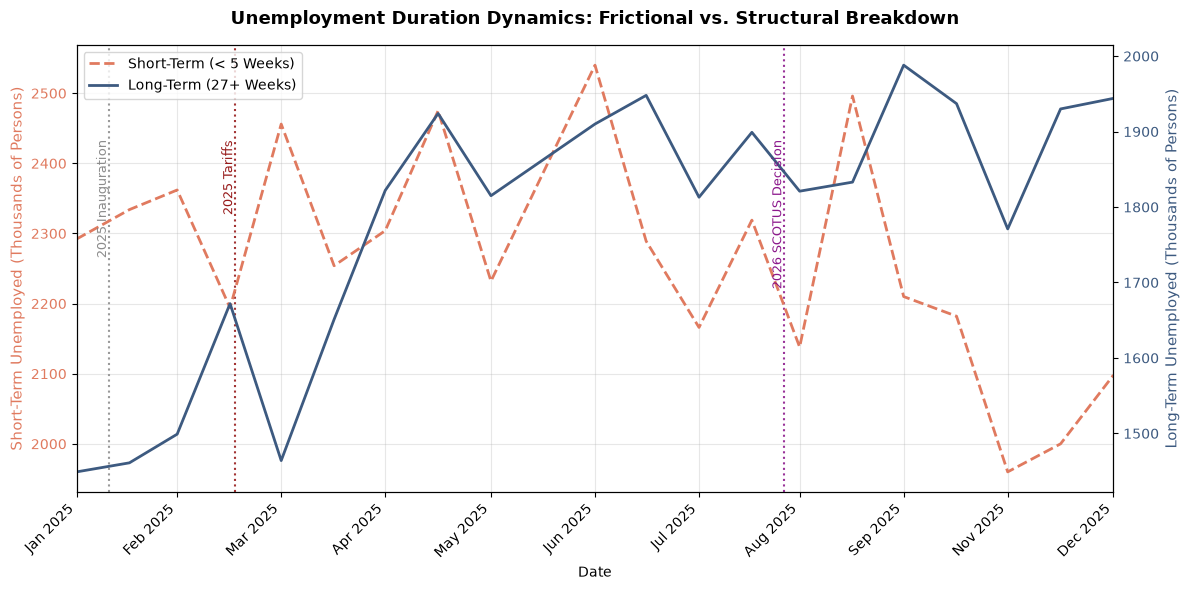

In [20]:
df_duration = df_kpi[['Unemployed Less than 5 Weeks', 'Unemployed Longer than 27 Weeks']].dropna()

fig, ax1 = plt.subplots(figsize = (12, 6))

color_short = '#e07a5f'
line1 = ax1.plot(df_duration.index, df_duration['Unemployed Less than 5 Weeks'], 
                 color = color_short, linestyle = '--', linewidth = 2, label = 'Short-Term (< 5 Weeks)')
ax1.set_ylabel('Short-Term Unemployed (Thousands of Persons)', color = color_short, fontsize = 11)
ax1.tick_params(axis = 'y', labelcolor = color_short)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
color_long = '#3d5a80'
line2 = ax2.plot(df_duration.index, df_duration['Unemployed Longer than 27 Weeks'], 
                 color = color_long, linewidth = 2, label = 'Long-Term (27+ Weeks)')
ax2.set_ylabel('Long-Term Unemployed (Thousands of Persons)', color = color_long, fontsize = 11)
ax2.tick_params(axis = 'y', labelcolor = color_long)
ax2.grid(False)

evt_20jan2025 = datetime(2025, 1, 20)
evt_4apr2025 = datetime(2025, 4, 4)
evt_20feb2026 = datetime(2026, 2, 20)

y2_max = df_duration['Unemployed Longer than 27 Weeks'].max()

for evt, label, col in [(evt_20jan2025, "2025 Inauguration", "gray"),
                        (evt_4apr2025, "2025 Tariffs", "darkred"),
                        (evt_20feb2026, "2026 SCOTUS Decision", "purple")]:
    ax1.axvline(evt, color = col, linestyle = ':', alpha = 0.8, zorder = 1)
    ax2.text(evt, y2_max * 0.95, label, rotation = 90, va = 'top', ha = 'right', fontsize = 9, color = col, alpha = 0.9)

ax1.set_title("Unemployment Duration Dynamics: Frictional vs. Structural Breakdown", fontsize = 13, pad = 15, weight = 'bold')
ax1.set_xlabel("Date")
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%B'))
ax1.set_xlim(start, df_duration.index.max())
ax1.set_xticklabels(x_labels, rotation = 45, ha = 'right')

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc = 'upper left', frameon = True)

plt.tight_layout()
plt.show()

## Metric 4: Disengaged Labor Capacity (NILFWJN)
### Not in Labor Force, Wants a Job

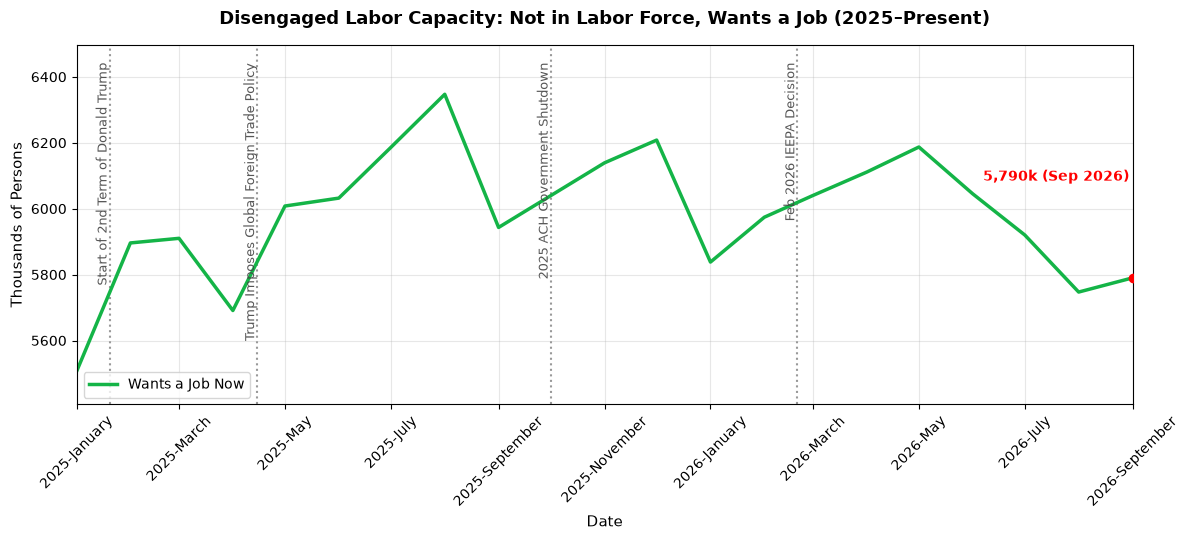

In [21]:
df_latent = df_kpi[['Not in Labor Force, Wants a Job']].dropna()

plt.figure(figsize=(12, 5.5))
plt.plot(df_latent.index, df_latent['Not in Labor Force, Wants a Job'], color="#14b447", linewidth=2.5, label='Wants a Job Now')

y_max = df_latent['Not in Labor Force, Wants a Job'].max()
y_min = df_latent['Not in Labor Force, Wants a Job'].min()

ax = plt.gca()

for date_str, label in events.items():
    evt = pd.to_datetime(date_str)
    
    # Draw vertical line
    ax.axvline(evt, color='gray', linestyle=':', alpha=0.8, zorder=1)
    ax.text(x=evt, 
            y=0.95, 
            s=label, 
            transform=ax.get_xaxis_transform(),
            rotation=90, 
            va='top', 
            ha='right', 
            fontsize=9, 
            color='#444444', 
            alpha=0.9)
    
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%B'))
plt.xlim(start, df_latent.index.max())
plt.ylim(y_min - 100, y_max + 150)
plt.xticks(rotation=45)

plt.title("Disengaged Labor Capacity: Not in Labor Force, Wants a Job (2025–Present)", 
          fontsize = 13, 
          pad = 15, 
          weight = 'bold')
plt.ylabel("Thousands of Persons", fontsize = 11)
plt.xlabel("Date", fontsize = 11)
plt.grid(alpha = 0.3)
plt.legend(loc = 'lower left')

latest_date = df_latent.index[-1]
latest_val = df_latent['Not in Labor Force, Wants a Job'].iloc[-1]

plt.scatter(latest_date, latest_val, color = 'red', zorder = 5)
plt.annotate(f"{int(latest_val):,}k ({latest_date.strftime('%b %Y')})", 
             (latest_date, latest_val), 
             textcoords = "offset points", 
             xytext= (-55, 70), 
             ha = 'center', 
             weight = 'bold', 
             color = 'red')

plt.tight_layout()
plt.show()

## Metric 5: Cross-Sectional Demographic Disparity
### Segmented Unemployment Rates Across Racial, Gender, and Generational

C:\Users\library\AppData\Local\Temp\ipykernel_9624\1862884671.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x = 'Demographic', y = 'Unemployment Rate', data = df_snapshot, palette = colors)


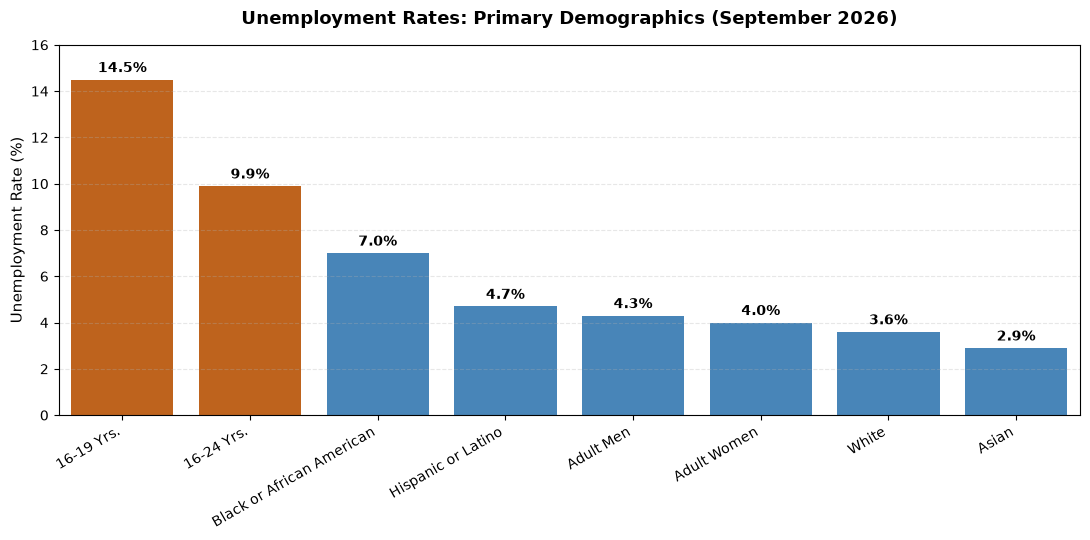

In [22]:
demo_series = {
    'LNS14000003': 'White',
    'LNS14000006': 'Black or African American',
    'LNS14032183': 'Asian',
    'LNS14000009': 'Hispanic or Latino',
    'LNS14000001': 'Adult Men',
    'LNS14000002': 'Adult Women',
    'LNS14024887': '16-24 Yrs.',
    'LNS14000012': '16-19 Yrs.'
}

df_demo = web.DataReader(list(demo_series.keys()), 'fred', start, end)
df_demo.rename(columns = demo_series, inplace = True)

latest_row = df_demo.dropna().tail(1)
target_month_str = latest_row.index[0].strftime('%B %Y')

df_snapshot = pd.DataFrame({
    'Demographic': latest_row.columns,
    'Unemployment Rate': latest_row.values[0]
}).sort_values(by='Unemployment Rate', ascending=False)

plt.figure(figsize=(11, 5.5))

colors = ["#d95f028d" if 'Yrs' in cat else "#3587cb" for cat in df_snapshot['Demographic']]
ax = sns.barplot(x = 'Demographic', y = 'Unemployment Rate', data = df_snapshot, palette = colors)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f"{height:.1f}%", 
                (p.get_x() + p.get_width() / 2., height), 
                ha = 'center', va = 'center', xytext = (0, 8), 
                textcoords = 'offset points', fontsize = 10, weight = 'bold')

plt.title(f"Unemployment Rates: Primary Demographics ({target_month_str})", fontsize = 13, pad = 15, weight = 'bold')
plt.ylabel("Unemployment Rate (%)", fontsize = 11)
plt.xlabel("")
plt.xticks(rotation = 30, ha = 'right')

plt.ylim(0, df_snapshot['Unemployment Rate'].max() + 1.5)
plt.grid(axis = 'y', alpha = 0.3, linestyle = '--')

plt.tight_layout()
plt.show()

## Metric 6: Growth and Loss
### Industry Breakdown of Net Employment Shifts

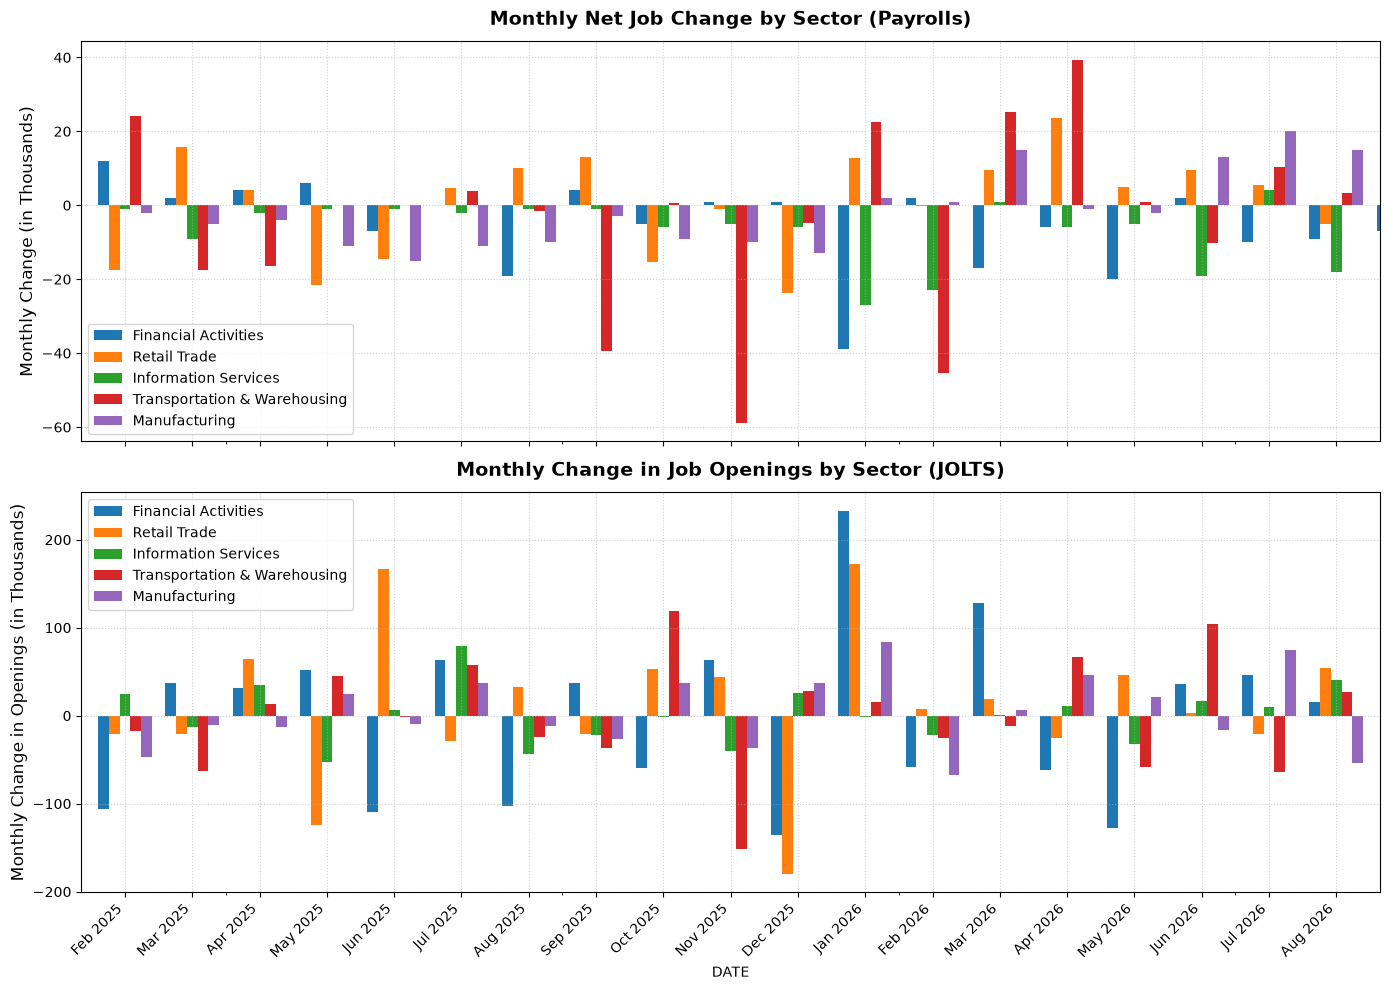

In [23]:
emp_mx = {
    'Financial Activities': 'USFIRE',
    'Retail Trade': 'USTRADE',
    'Information Services': 'USINFO',
    'Transportation & Warehousing': 'CES4300000001',
    'Manufacturing': 'MANEMP'
}

jolts_mx = {
    'Financial Activities': 'JTU5200JOL',
    'Retail Trade': 'JTS4400JOL',
    'Information Services': 'JTU5100JOL',
    'Transportation & Warehousing': 'JTU480099JOL',
    'Manufacturing': 'JTS3000JOL'
}

df_emp = web.DataReader(list(emp_mx.values()), 'fred', start, end)
df_emp.rename(columns={v: k for k, v in emp_mx.items()}, inplace=True)
df_emp_growth = df_emp.dropna(how='all').diff().dropna()

df_jolts = web.DataReader(list(jolts_mx.values()), 'fred', start, end)
df_jolts.rename(columns={v: k for k, v in jolts_mx.items()}, inplace=True)
df_jolts_growth = df_jolts.dropna(how='all').diff().dropna() # Fixed variable name

# plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

df_emp_growth.plot(kind='bar', ax=ax1, width=0.8)
ax1.set_title('Monthly Net Job Change by Sector (Payrolls)', fontsize=14, fontweight='bold', pad=12)
ax1.set_ylabel('Monthly Change (in Thousands)', fontsize=12)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='lower left', frameon=True)

df_jolts_growth.plot(kind='bar', ax=ax2, width=0.8)
ax2.set_title('Monthly Change in Job Openings by Sector (JOLTS)', fontsize=14, fontweight='bold', pad=12)
ax2.set_ylabel('Monthly Change in Openings (in Thousands)', fontsize=12)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc='upper left', frameon=True)

ax2.set_xticklabels([d.strftime('%b %Y') for d in df_jolts_growth.index], rotation=45, ha='right')

plt.tight_layout()
plt.show()

## All Other Sectors: Government, Wholesale Trade, Business & Professional, Leisure & Hospitality, Mining & Logging, Construction, Utilities, Education & Health

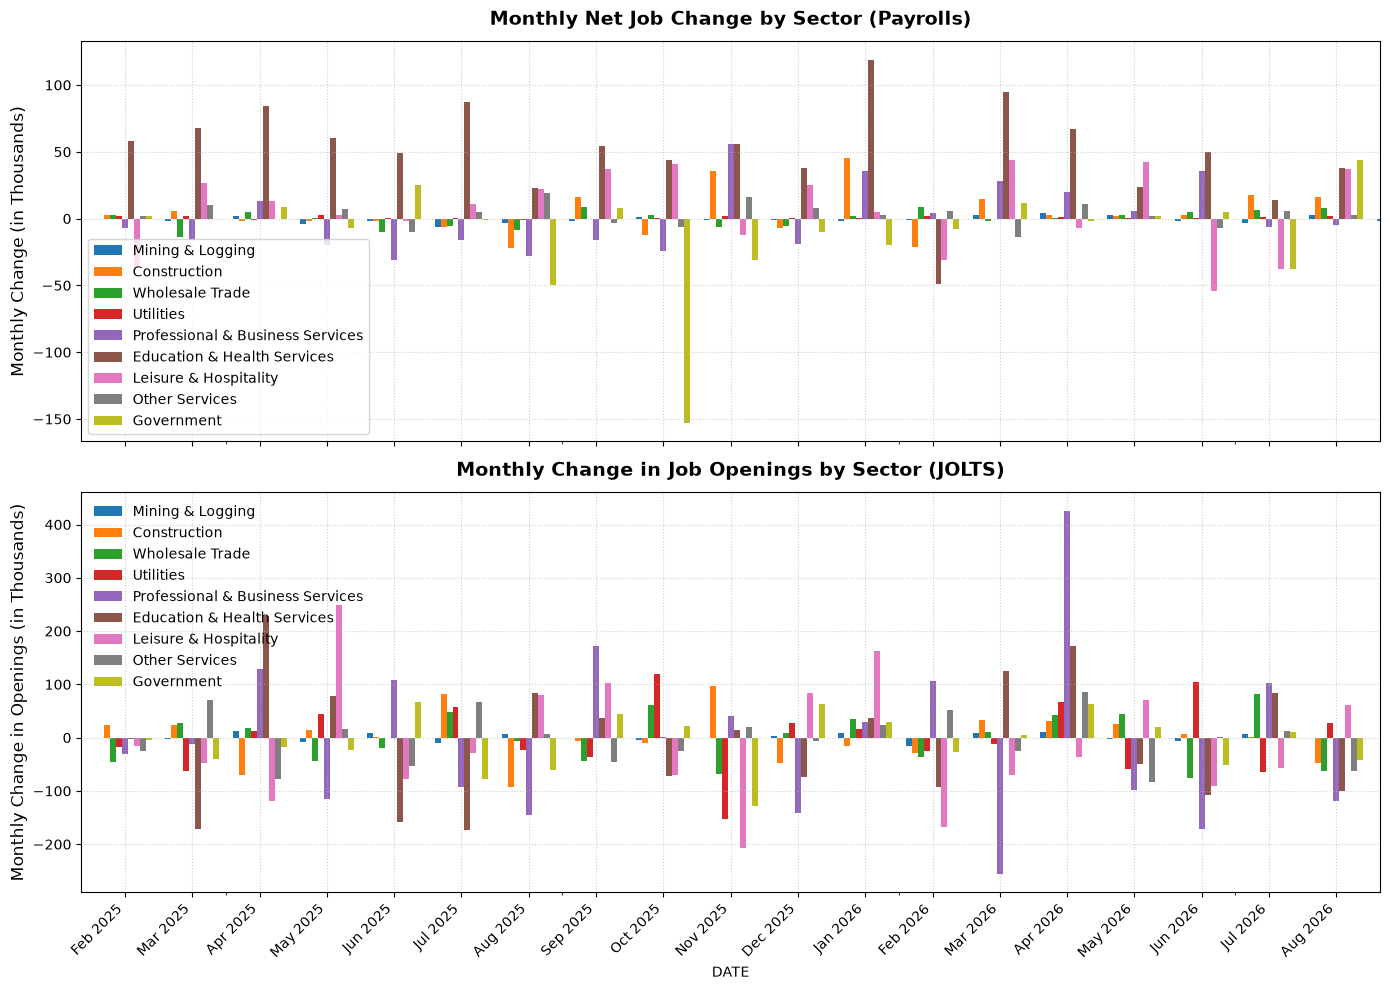

In [24]:
emp_mx_other = {
    'Mining & Logging': 'USMINE',
    'Construction': 'USCONS',
    'Wholesale Trade': 'USWTRADE',
    'Utilities': 'CES4422000001',
    'Professional & Business Services': 'USPBS',
    'Education & Health Services': 'USEHS',
    'Leisure & Hospitality': 'USLAH',
    'Other Services': 'USSERV',
    'Government': 'USGOVT'
}

jolts_mx_other = {
    "Mining & Logging": "JTU110099JOL",
    "Construction": "JTS2300JOL",
    "Wholesale Trade": "JTU4200JOL",
    "Utilities": "JTU480099JOL",
    "Professional & Business Services": "JTS540099JOL",
    "Education & Health Services": "JTS6000JOL",
    "Leisure & Hospitality": "JTS7000JOL",
    "Other Services": "JTU8100JOL",
    "Government": "JTS9000JOL"
}

df_emp_o = web.DataReader(list(emp_mx_other.values()), 'fred', start, end)
df_emp_o.rename(columns={v: k for k, v in emp_mx_other.items()}, inplace=True)
df_emp_growth_o = df_emp_o.dropna(how='all').diff().dropna()

df_jolts_o = web.DataReader(list(jolts_mx_other.values()), 'fred', start, end)
df_jolts_o.rename(columns={v: k for k, v in jolts_mx_other.items()}, inplace=True)
df_jolts_growth_o = df_jolts_o.dropna(how='all').diff().dropna()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Monthly Net Job Changes (Payrolls)
df_emp_growth_o.plot(kind='bar', ax=ax1, width=0.8)
ax1.set_title('Monthly Net Job Change by Sector (Payrolls)', fontsize=14, fontweight='bold', pad=12)
ax1.set_ylabel('Monthly Change (in Thousands)', fontsize=12)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='lower left', frameon=True)

# Monthly Change in Job Openings (JOLTS)
df_jolts_growth_o.plot(kind='bar', ax=ax2, width=0.8)
ax2.set_title('Monthly Change in Job Openings by Sector (JOLTS)', fontsize=14, fontweight='bold', pad=12)
ax2.set_ylabel('Monthly Change in Openings (in Thousands)', fontsize=12)
ax2.grid(True, linestyle=':', alpha=0.6)
#ax2.legend(loc='upper left', frameon=True)
ax2.legend(frameon=False)
ax2.set_xticklabels([d.strftime('%b %Y') for d in df_jolts_growth_o.index], rotation=45, ha='right')
plt.tight_layout()
plt.show()


# Conlusions and Observations

### Jobs - 6 October 2026

#### There goes the neighborhood...

**Notice:** I will not review August's jobs report in this report beyond the revisions from September.

The United States created 29,000 new payrolls in the month of September 2026, continuing a trend of low or slowing job growth and steady unemployment.


#### Problem Areas and Highlights

Healthcare industry employers saw new net gains in the month of September, netting 17,000 new jobs created. However the pace was below the 33,000 monthly gain of the previous 12 months.

The unemplyoment rate for black Americans increased in September to 7.0%, up from 6.0% in August.

All other races changed little from the previous month.

Notable net losses are in the same sectors as the previous 12 months.

Financial services: -7,000 jobs in September, -27,000 since July 2026. -129,000 since May 2025.

Information: -10,000 jobs in September, -24,000 since July 2026.  -42,000 since May 2025. 

Professional and Business Services: - 9,000 jobs in September, -20,000 since July 2026.


#### Observation

September was a substantially slow month by historcial standards.

Outside of recessions or the pandemic, the U.S. has not had a monthly net gain lower since:

• August 2025: +22,000 jobs.

• May 2019: +15,000 jobs. *Note: Driven by GM labor strikes.*

Relying on the same parameters, non-inculsive of pandemics or recessions, prior to 2019:

• May 2003: +29,000 jobs.

• January 2003: +2,000 jobs.

• April 2002: +21,000 jobs.

April 2002 through May 2003 is most notably characterized by a jobless recovery from the "Dot Com Bubble."

#### Opinion

We are likely looking at a bust, not a bubble.

As inflation measures have been re-formulated to reflect a slightly lower metric, wages are still outpaced.

Wage growth in September at 3.0% and the new inflation figure is 3.3%. 

It is likely that rates would hold steady as we head into the late year... 

However I am highly doubtful holding steady rates is going to result in more payrolls, higher wage growth, and inflation closer to 2.0%.

The late Ronald Reagan famously said, "the best form of welfare is a job."

It would appear America's opportunities for welfare are drier than a pinot noir to a teetotaler*.

*A person who completely abstains from alcohol.*



___

**Thank you for reading.**

___




### Jobs - 7 August 2026

#### Dry July

The labor market in the United States shrank in the month of July.

Non-farm payrolls saw a -23,000 net gain, highlighted by a -50,000 net gain in local governmeent education and a +30,000 net gain from private employers.

#### Problem Areas and Highlights

Healthcare industry employers continued to see net gains in the month of July, netting 22,000 new jobs created.

This figure, however, lags behind the 12-month rolling average of 36,000 heallth care jobs created from month-to-month.

Construction jobs also saw an increase of 22,000 new jobs created.

#### Unemployment, Availabillity, and Labor Force Participation

Starting on a different foot, labor force particiaption further fell by a net of 0.1% to 61.4%, a new multi-year low from the previous month.

Comparatively, unemployment fell by 0.1% to 4.1% in July down from 4.2% in June 2026.

The number of available jobs fell from 7.54 milliion in June 2026 to 7.36 million in July.

The quits rate remained flat at 2.0% while involutary layoffs and discharges held steady at 1.1%.

Hiring rates held steady at 3.4%, no net difference there.

Unemployment for adults 25 years or older with less than a High School diploma or a High School diploma without college had negligible employment changes.

Similarly, Unemployment for adults 25 years or older with some college or an associate, and bachelor's or higher, also had negligible employment changes.

#### Notable Details

Unemployment for Teenages, age 16 - 19, dropped 2.5% from 14.6% to 12.1%, constituing the sharpest net change.

Followed by Hiispancis, all ages, dropping 0.6% from 5.2% to 4.6%.

Black americans and African-Americcns, all ages, dropped 0.3% from 6.3% to 6.3%.

Adult men, adult women, Asian Americans, and White Americans, all had negligible or flat changes, as the Employment-Population Ratio continues declining.

The United States population grew by rougly 116,000 civilians in July 2026.


#### Observation

The approximate 50,000 loval government jobs lost typically is a result of summertime instructor positions, teaching and research assistants, lecturers, and related roles.

The categories of postions are non-exhaustive and are cyclical in that state-funded education fluctuations are a predictable feature of the broader labor market. 

Next.

Leisure and hospitatlitty reduced by approximately 40,000, likely in response to the conclusion of the FIFA World Cup.

Without these two leading factors, labor growth would still whiff growth expectations by approxiately 19.2% and greatly miss break-even rates during normalized immigration and trade.

#### Opinion

We live in the United States, one of three major political powers on planet Earth.

if a superpower economy’s labor market is sensitive enough to be pushed into negative territory by predictable calendar events, it signals a loss of any "cushion" it might have been pushin'.

Labor prductivity in 2023 and 2024 grew 1.6% and 2.4%, whereas Real GPD growth came out at 2.9% and 2.8%, respectively.

In 2025, GDP and Labor productivity grew 2.2% annually, but do not let these figures appear to match intentionally.

For 2026, labor productivity grew 0.3% in Q1 and 1.4% in Q2, while GPD grew 2.1% and 1.5% respectively.

But, hourly compensation shrank 0.5% in Q1 and 3.1% in Q2 of 2026.

Just what are we really working towards? As it appears, there will be nothing to show for it when we get there.
___

**Thank you for reading. If you would like more in-depth analysis, reporting, dashboards, systems models or automations, you must already know how to reach me.**

___




### Jobs - 3 July 2026

#### The land of opportunity looks like it's mysteriously run out of real estate.

Putting things midly, the United States created approximately **57,000 non-farm payrolls**  in the month of June. 

Key gains were found in healthcare, netting **22,000 jobs** and social assistance with **25,000 jobs**.

Biggest losers were leisure and hospitality, netting **-61,000 jobs** in June. Nearly evvery other industry saw negligble growth.

April's previous figure was *revised downward* by 31,000, now showing **148,000 jobs created for the month.**

Similarly, May was revised downward by 43,000, now showing **129,000 jobs created for the month.**

#### This wasn't the soup we ordered. In fact, we haven't placed an order yet.

Jobs numbers falling below expectations is nothing new for this administration. At this point it is an expectation, very far away from a surprise.

Since January 2025, the United States has added a measily **668,000 jobs in 18 months.** 

Of that 668,000, a whopping **552,000 jobs were created in 2026**.

Even more shocking is the realization that ***462,000 of those jobs were created in March, April, or May 2026.***

Only 31,000 jobs were created in January, February, and June 2026 <u>*combined</u>.*

#### There's gold in those rivers.

Long-term unemployment, greater than 27 weeks, and short term unemployment, fewer than 27 weeks, decreased significatly, as did disengaged workers.

Disengaged workers, specifically, reduced by 142,000 persons in the month of June.

Unemployment amoung younger people, aged 16-19 decreased from 14.7% to now 14.6%.

Unemployment in adult men and women share a simliar decrease of 0.1%.

Overall, the unemployment rate changed little from 4.3%, now 4.2%. 

Interestingly enough, unemployment rates for <u>Black Americans and those with an associate's degree, bachelor's degree, or higher</u> **remained unchanged.**

The same rates for those <u>over the age of 25 years old, with less than a high school diploma</u>, **decreased 0.5%.**

#### What's there left to say?

The rivers are not flowing. The U.S. has created 37,000 per month, on average. 

Putting things in perspective, that is the equivalent of about three (3) Division I colleges or universities in the United States.

##### The United States has 365 Division I Colleges or Universities.

It's a great time to convince your parents or grandparents to soak in what remains of the Social Security Administration.

___

**Thank you for reading. This is the one and only major economic indicator we're touching today, however the remaining have been or are being reformatted for style points.** 

**Next week I'm touching on <u>National Gas Prices</u>, <u>Healthcare Services and Commodities</u>, and <u>Consumer Inflation and Expenditures</u>.**

**In two weeks, we're going to address automotive and food; perhaps we'll start looking at energy as well. See you next week.**

___

## Happy Fourth of July and Happy 250th to the United States of America.

___


#### Update Schedule

- ***Labor and Employment KPIs - Aug 7, 2026***

    1. `PAYEMS`: **Total Nonfarm Payroll Employment**
    2. `CIVPART`: **Labor Force Participation Rate**
    3. `EMRATIO`: **Employment-to-Population Ratio**
    4. `UEMPLT5`: **Unemployed Less than 5 Weeks**
    5. `UEMP27OV`: **Unemployed Longer than 27 Weeks**
    6. `NILFWJN`: **Not in Labor Force, Wants a Job**

- ***Demographics - Aug 7, 2026***

    7. `LNS14000003`: **White Unemployment Rate**
    8. `LNS14000006`: **Black or African American Unemployment Rate**
    9. `LNS14032183`: **Asian Unemployment Rate**
    10. `LNS14000009`: **Hispanic or Latino Unemployment Rate**
    11. `LNS14000001`: **Adult Men Unemployment Rate**
    12. `LNS14000002`: **Adult Women Unemployment Rate**
    13. `LNS14024887`: **16-24 Yrs. Unemployment Rate**
    14. `LNS14000012`: **16-19 Yrs. Unemployment Rate**

#### Data Changelog / Notes

#### ***Review and analysis publishing when information is best available.***